In [ ]:
import matplotlib
import numpy as np
import pandas as pd
import scipy
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.1
Scikit-learn: 1.9.1
SciPy: 1.18.1


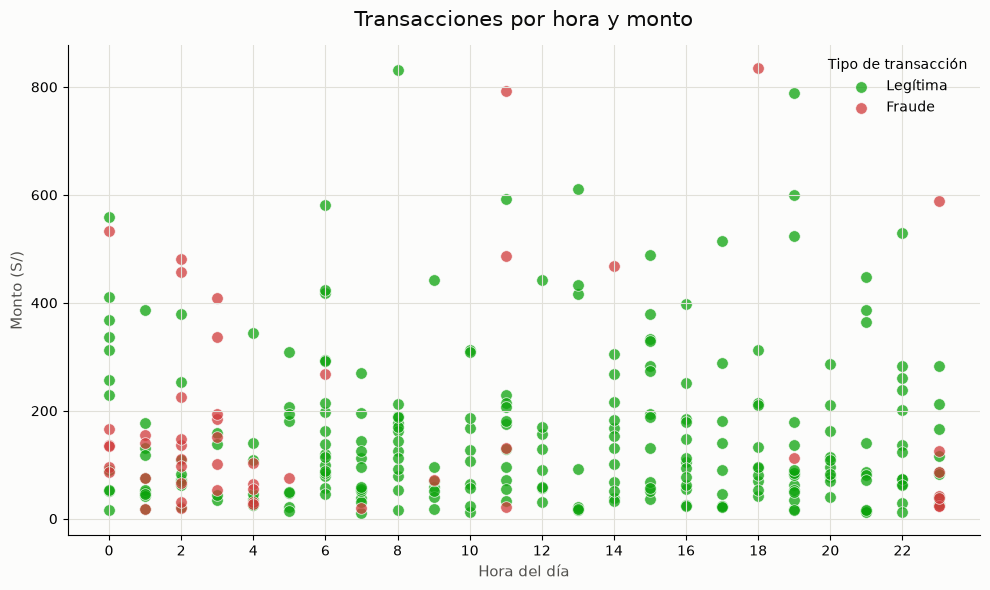

Total transacciones: 300 | Fraudes: 50


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

n = 300

hora = np.random.randint(0, 24, n)

monto = np.random.exponential(scale=150, size=n) + 10

# Fraude más probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = (
    0.03
    + 0.35 * ((hora <= 5) | (hora >= 23))
    + 0.25 * (monto > 400)
)

prob_fraude = np.clip(prob_fraude, 0, 0.9)

es_fraude = (np.random.rand(n) < prob_fraude).astype(int)

transacciones = pd.DataFrame({
    "hora": hora,
    "monto": monto,
    "es_fraude": es_fraude
})

colores = {
    0: "#0ca30c",
    1: "#d03b3b"
}  # verde = legítima, rojo = fraude

etiquetas = {
    0: "Legítima",
    1: "Fraude"
}

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="#fcfcfb"
)

ax.set_facecolor("#fcfcfb")

for valor in [0, 1]:
    subset = transacciones[
        transacciones["es_fraude"] == valor
    ]

    ax.scatter(
        subset["hora"],
        subset["monto"],
        s=70,
        alpha=0.75,
        c=colores[valor],
        edgecolors="white",
        linewidths=0.6,
        label=etiquetas[valor],
    )

ax.set_title(
    "Transacciones por hora y monto",
    fontsize=15,
    color="#0b0b0b",
    pad=14
)

ax.set_xlabel(
    "Hora del día",
    fontsize=11,
    color="#52514e"
)

ax.set_ylabel(
    "Monto (S/)",
    fontsize=11,
    color="#52514e"
)

ax.set_xticks(range(0, 24, 2))

ax.grid(
    True,
    color="#e1e0d9",
    linewidth=0.8
)

ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    title="Tipo de transacción",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

plt.show()

print(
    "Total transacciones:",
    len(transacciones),
    "| Fraudes:",
    transacciones["es_fraude"].sum()
)